In [45]:
%pip install tensorflow==2.20.0 scikit-learn seaborn matplotlib pandas numpy sastrawi nltk wordcloud

Note: you may need to restart the kernel to use updated packages.


In [46]:
import os
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import json
import math
from collections import Counter

import datetime as dt
import re  # Modul untuk bekerja dengan ekspresi reguler
import string  # Berisi konstanta string, seperti tanda baca
from nltk.tokenize import word_tokenize  # Tokenisasi teks
from nltk.corpus import stopwords  # Daftar kata-kata berhenti dalam teks

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory  # Stemming (penghilangan imbuhan kata) dalam bahasa Indonesia
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory  # Menghapus kata-kata berhenti dalam bahasa Indonesia

from wordcloud import WordCloud  # Membuat visualisasi berbentuk awan kata (word cloud) dari teks

import nltk  # Import pustaka NLTK (Natural Language Toolkit).
nltk.download('punkt')  # Mengunduh dataset yang diperlukan untuk tokenisasi teks.
nltk.download('punkt_tab')  # Kompatibel untuk NLTK versi baru yang membutuhkan resource punkt_tab.
nltk.download('stopwords')  # Mengunduh dataset yang berisi daftar kata-kata berhenti (stopwords) dalam berbagai bahasa.

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [47]:
DATA_PATH = Path("content/reviews_hok.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "File /content/reviews_hok.csv belum ditemukan. Jalankan notebook scrapping.ipynb terlebih dahulu."
    )

df = pd.read_csv(DATA_PATH)
print("Shape data awal:", df.shape)
df.head()

Shape data awal: (12000, 9)


,review_id,app_id,app_name,user_name,score,content,thumbs_up,at,app_version
0,2c793cc6-a533-4756-899c-929fe0905f1f,com.levelinfinite.sgameGlobal,Honor of King,Muhammad Ramadani,5,"game nya seru, developer nya baik, heronya balance daripada moba lain. hal yang aku permasalahkan; sering kali layar...",11,2026-04-03 14:50:36,11.3.1.8
1,03d587fa-daa9-4a40-b7c0-31ad6207ec45,com.levelinfinite.sgameGlobal,Honor of King,Andriyanto,2,"tolong perbaiki peforma peningkatan sinyal nya, kadang yang diutamakan itu pengalaman bermain, tolong perbaiki serve...",2,2026-04-23 17:57:13,11.3.1.9
2,f9f2926a-cfd2-4c77-b668-48813c845d28,com.levelinfinite.sgameGlobal,Honor of King,Andika,2,"gamenya udah bagus cuma ada kekurangan di fitur download, yaitu skin dalam match (yang dimiliki) sama yang (belum di...",1,2026-04-25 07:25:37,11.3.1.9
3,6febf65b-1bcd-4893-879a-03b7679ea16c,com.levelinfinite.sgameGlobal,Honor of King,icooo,1,"game rusak game rusak, lain kali kalo update jangan cuma mikirin skin,collab,dll. pentingin juga optimalisasi jaring...",0,2026-04-27 08:59:50,11.3.1.9
4,7a0f84f8-5c43-497a-b6c2-35b045d29061,com.levelinfinite.sgameGlobal,Honor of King,Nur Juminati,5,"Suka banget sama game nya, soalnya hero nya juga kebanyakan cakep-cakep:b. Cuma ya.. Kekurangan nya itu cuma satu, j...",1,2026-04-24 00:44:56,11.3.1.9


In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    12000 non-null  str  
 1   app_id       12000 non-null  str  
 2   app_name     12000 non-null  str  
 3   user_name    12000 non-null  str  
 4   score        12000 non-null  int64
 5   content      12000 non-null  str  
 6   thumbs_up    12000 non-null  int64
 7   at           12000 non-null  str  
 8   app_version  9008 non-null   str  
dtypes: int64(2), str(7)
memory usage: 843.9 KB


In [49]:
clean_df = df.dropna()
clean_df = clean_df.drop_duplicates()

clean_df.info()

<class 'pandas.DataFrame'>
Index: 9008 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   review_id    9008 non-null   str  
 1   app_id       9008 non-null   str  
 2   app_name     9008 non-null   str  
 3   user_name    9008 non-null   str  
 4   score        9008 non-null   int64
 5   content      9008 non-null   str  
 6   thumbs_up    9008 non-null   int64
 7   at           9008 non-null   str  
 8   app_version  9008 non-null   str  
dtypes: int64(2), str(7)
memory usage: 703.8 KB


In [50]:
display(clean_df["score"].value_counts().sort_index())

score
1    2936
2     869
3     979
4    1088
5    3136
Name: count, dtype: int64

In [51]:
clean_df = clean_df.copy()
clean_df["sentiment_seed"] = clean_df["score"].astype(int).map(
    lambda score: "negative" if score <= 2 else ("neutral" if score == 3 else "positive")
)

print("Distribusi score:")
display(clean_df["score"].value_counts().sort_index())

print("Total data untuk training:", len(clean_df))


Distribusi score:


score
1    2936
2     869
3     979
4    1088
5    3136
Name: count, dtype: int64

Total data untuk training: 9008


Mencari Slangword

In [52]:
INPUT_FILE = "content/reviews_hok.csv"
TEXT_COLUMN = "content"

MIN_FREQ = 5
OUTPUT_JSON = "slangwords_hok_scored.json"
OUTPUT_CSV = "slangwords_hok_scored.csv"
OUTPUT_STRICT_CSV = "slangwords_hok_scored_strict.csv"

# =========================
# LEXICON
# =========================

SLANG_LEXICON = {
    # negasi
    "gak": "tidak",
    "ga": "tidak",
    "gk": "tidak",
    "nggak": "tidak",
    "ngga": "tidak",
    "tdk": "tidak",
    "tak": "tidak",

    # kata informal umum
    "yg": "yang",
    "aja": "saja",
    "udah": "sudah",
    "udh": "sudah",
    "blm": "belum",
    "belom": "belum",
    "bgt": "banget",
    "banget": "sangat",
    "bgtt": "banget",
    "kalo": "kalau",
    "kalau": "jika",
    "buat": "untuk",
    "pas": "saat",
    "padahal": "sebenarnya",
    "kayak": "seperti",
    "kek": "seperti",
    "kyk": "seperti",
    "sama": "dengan",
    "sm": "sama",
    "dgn": "dengan",
    "dr": "dari",
    "krn": "karena",
    "karna": "karena",
    "tp": "tapi",
    "tpi": "tapi",
    "cuma": "hanya",
    "doang": "saja",
    "banget": "sangat",
    "nih": "ini",
    "sih": "",
    "dong": "",
    "lah": "",
    "deh": "",
    "kok": "mengapa",
    "emang": "memang",
    "emg": "memang",
    "mending": "lebih baik",
    "makin": "semakin",
    "gede": "besar",
    "kecil": "kecil",
    "burik": "buruk",
    "jelek": "buruk",
    "bagus": "baik",

    # pronomina informal
    "aku": "saya",
    "gue": "saya",
    "gw": "saya",
    "gua": "saya",
    "lu": "kamu",
    "lo": "kamu",
    "loe": "kamu",
    "dia": "ia",
    "mereka": "mereka",

    # ekspresi umum
    "mantap": "baik",
    "mantul": "mantap betul",
    "parah": "sangat buruk",
    "anjir": "ungkapan kaget",
    "anjay": "ungkapan kaget",
    "wkwk": "tertawa",
    "haha": "tertawa",
    "hehe": "tertawa",

    # variasi typo / informal game review
    "pengen": "ingin",
    "pingin": "ingin",
    "bikin": "membuat",
    "ngasih": "memberi",
    "ngasih": "memberikan",
    "dapet": "dapat",
    "dpt": "dapat",
    "mainin": "memainkan",
    "maen": "main",
    "mabar": "main bersama",
    "login": "masuk",
    "ngeleg": "lambat",
    "ngelag": "lambat",
    "lag": "lambat",
    "lemot": "lambat",
    "bug": "kesalahan sistem",
    "error": "kesalahan sistem",
    "crash": "keluar paksa",
    "freeze": "macet",
}

GAMING_LEXICON = {
    "hero": "karakter",
    "skin": "tampilan karakter",
    "rank": "peringkat",
    "match": "pertandingan",
    "game": "permainan",
    "moba": "genre permainan",
    "player": "pemain",
    "team": "tim",
    "tim": "tim",
    "server": "server",
    "ping": "latensi",
    "fps": "frame per second",
    "buff": "peningkatan kemampuan",
    "nerf": "penurunan kemampuan",
    "skill": "kemampuan",
    "ulti": "kemampuan utama",
    "ultimate": "kemampuan utama",
    "mmr": "peringkat pemain",
    "meta": "strategi populer",
    "lane": "jalur permainan",
    "jungler": "pemain hutan",
    "roam": "berpindah jalur",
    "roamer": "pemain pendukung",
    "gold": "sumber daya permainan",
    "exp": "pengalaman",
    "push": "menekan jalur",
    "war": "pertarungan tim",
    "afk": "tidak aktif",
    "bot": "pemain komputer",
    "toxic": "perilaku buruk",
    "skin": "tampilan karakter",
    "diamond": "mata uang permainan",
    "event": "acara permainan",
    "patch": "pembaruan",
    "update": "pembaruan",
}

# Kata baku/umum yang sebaiknya tidak dianggap slang.
FORMAL_STOPWORDS = {
    "dan", "di", "ke", "dari", "ini", "itu", "untuk", "dengan", "pada",
    "adalah", "sebagai", "dalam", "atau", "karena", "jika", "agar",
    "lebih", "sangat", "bisa", "akan", "sudah", "belum", "tidak",
    "yang", "saya", "kamu", "kami", "mereka", "orang", "ada",
    "jadi", "harus", "semua", "setiap", "saat", "terlalu",
}

# =========================
# PREPROCESSING
# =========================

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def tokenize_series(texts):
    tokens = []
    for text in texts:
        tokens.extend(clean_text(text).split())
    return tokens


# =========================
# RULES
# =========================

def has_repeated_char(word: str) -> bool:
    return bool(re.search(r"(.)\1{2,}", word))


def normalize_repeated_char(word: str) -> str:
    """
    Contoh:
    enakkk -> enak
    baguss -> bagus
    mantapp -> mantap
    """
    return re.sub(r"(.)\1{2,}", r"\1", word)


def is_short_abbreviation(word: str) -> bool:
    return len(word) <= 4 and not word.isdigit()


def is_noise(word: str) -> bool:
    if len(word) <= 1:
        return True
    if word.isdigit():
        return True
    if re.fullmatch(r"[0-9]+[a-z]*", word):
        return True
    return False


def classify_word(word: str):
    """
    Return:
    normalisasi, category, method
    """

    if word in SLANG_LEXICON:
        return SLANG_LEXICON[word], "informal_slang", "direct_lexicon"

    if word in GAMING_LEXICON:
        return GAMING_LEXICON[word], "gaming_term", "direct_lexicon"

    repeated_normalized = normalize_repeated_char(word)
    if repeated_normalized != word:
        if repeated_normalized in SLANG_LEXICON:
            return SLANG_LEXICON[repeated_normalized], "informal_slang", "repeated_char_normalization"
        if repeated_normalized in FORMAL_STOPWORDS:
            return repeated_normalized, "informal_slang", "repeated_char_normalization"
        return repeated_normalized, "informal_slang", "repeated_char_pattern"

    # kandidat singkatan informal
    if is_short_abbreviation(word):
        if word not in FORMAL_STOPWORDS:
            return None, "informal_slang", "short_abbreviation_pattern"

    return None, None, None


# =========================
# CONFIDENCE SCORE
# =========================

def compute_confidence(word, freq, category, method):
    """
    Score dibuat agar:
    - direct lexicon + frekuensi tinggi mendekati 0.99
    - pattern-based lebih rendah
    """

    # frequency score logarithmic supaya kata sangat sering dominan,
    # tapi tidak membuat semua kata otomatis 0.99
    freq_score = min(math.log1p(freq) / math.log1p(3500), 1.0)

    method_weight = {
        "direct_lexicon": 0.55,
        "repeated_char_normalization": 0.42,
        "repeated_char_pattern": 0.32,
        "short_abbreviation_pattern": 0.25,
    }.get(method, 0.2)

    category_weight = {
        "informal_slang": 0.25,
        "gaming_term": 0.20,
        "domain_term": 0.18,
    }.get(category, 0.15)

    score = method_weight + category_weight + (freq_score * 0.25)

    return round(min(score, 0.99), 3)


# =========================
# MAIN EXTRACTOR
# =========================

def extract_slangwords(
    input_file=INPUT_FILE,
    text_column=TEXT_COLUMN,
    min_freq=MIN_FREQ,
):
    df = pd.read_csv(input_file)

    if text_column not in df.columns:
        raise ValueError(
            f"Kolom '{text_column}' tidak ditemukan. "
            f"Kolom tersedia: {list(df.columns)}"
        )

    tokens = tokenize_series(df[text_column].fillna(""))
    frequencies = Counter(tokens)

    results = []

    for word, freq in frequencies.items():
        if freq < min_freq:
            continue

        if is_noise(word):
            continue

        normalisasi, category, method = classify_word(word)

        if category is None:
            continue

        confidence_score = compute_confidence(
            word=word,
            freq=freq,
            category=category,
            method=method,
        )

        results.append({
            "slangword": word,
            "normalisasi": normalisasi,
            "frequency": freq,
            "confidence_score": confidence_score,
            "category": category,
            "method": method,
        })

    results = sorted(
        results,
        key=lambda x: (-x["confidence_score"], -x["frequency"], x["slangword"])
    )

    return results


# =========================
# RUN
# =========================

if __name__ == "__main__":
    results = extract_slangwords()

    # JSON
    with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
        json.dump(results, f, ensure_ascii=False, indent=2)

    print("Saved:", OUTPUT_JSON)

Saved: slangwords_hok_scored.json


In [53]:
SLANGWORDS_PATH = Path("slangwords_hok_scored.json")
if not SLANGWORDS_PATH.exists():
    raise FileNotFoundError(
        "File slangwords_hok_scored.json tidak ditemukan di root project."
    )

with SLANGWORDS_PATH.open("r", encoding="utf-8") as f:
    slangwords_raw = json.load(f)

# Ubah list of dict JSON menjadi mapping: slankword -> normalisasi
slangwords = {
    item["slangword"].strip().lower(): item["normalisasi"].strip().lower()
    for item in slangwords_raw
    if item.get("slangword") and item.get("normalisasi")
}

print(f"Total slangwords termuat: {len(slangwords)}")


Total slangwords termuat: 137


In [54]:
def fix_slangwords(text):
    words = text.split()
    fixed_words = []

    for word in words:
        key = word.lower()
        if key in slangwords:
            fixed_words.append(slangwords[key])
        else:
            fixed_words.append(word)

    fixed_text = ' '.join(fixed_words)
    return fixed_text


In [55]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka

    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text, preserve_line=True)
    return text

def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()

    # Memecah teks menjadi daftar kata
    words = text.split()

    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]

    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)

    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

In [56]:
# Membersihkan teks dan menyimpannya di kolom 'text_clean'
clean_df['text_clean'] = clean_df['content'].apply(cleaningText)

# Mengubah huruf dalam teks menjadi huruf kecil dan menyimpannya di 'text_casefoldingText'
clean_df['text_casefoldingText'] = clean_df['text_clean'].apply(casefoldingText)

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
clean_df['text_slangwords'] = clean_df['text_casefoldingText'].apply(fix_slangwords)

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenizingText)

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
clean_df['text_stopword'] = clean_df['text_tokenizingText'].apply(filteringText)

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
clean_df['text_akhir'] = clean_df['text_stopword'].apply(toSentence)

In [57]:
import csv
import requests
from io import StringIO

# Membaca data kamus kata-kata positif dari GitHub
lexicon_positive = dict()

response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_positive[row[0]] = int(row[1])
        # Menambahkan kata-kata positif dan skornya ke dalam kamus lexicon_positive
else:
    print("Failed to fetch positive lexicon data")
 
# Membaca data kamus kata-kata negatif dari GitHub
lexicon_negative = dict()
 
response = requests.get('https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv')
# Mengirim permintaan HTTP untuk mendapatkan file CSV dari GitHub
 
if response.status_code == 200:
    # Jika permintaan berhasil
    reader = csv.reader(StringIO(response.text), delimiter=',')
    # Membaca teks respons sebagai file CSV menggunakan pembaca CSV dengan pemisah koma
 
    for row in reader:
        # Mengulangi setiap baris dalam file CSV
        lexicon_negative[row[0]] = int(row[1])
        # Menambahkan kata-kata negatif dan skornya dalam kamus lexicon_negative
else:
    print("Failed to fetch negative lexicon data")

In [63]:
# Fungsi untuk menentukan polaritas sentimen berbasis lexicon
def sentiment_analysis_lexicon_indonesia(tokens):
    score = 0

    for word in tokens:
        # Tambah bobot jika kata ada di kamus positif
        score += lexicon_positive.get(word, 0)
        # Kurangi bobot jika kata ada di kamus negatif
        score += lexicon_negative.get(word, 0)

    if score < 0:
        polarity = 'negative'
    elif score >= 0:
        polarity = 'positive'

    return score, polarity

In [64]:
results = clean_df['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
clean_df['polarity_score'] = results[0]
clean_df['polarity'] = results[1]
print(clean_df['polarity'].value_counts())

polarity
negative    5906
positive    3102
Name: count, dtype: int64


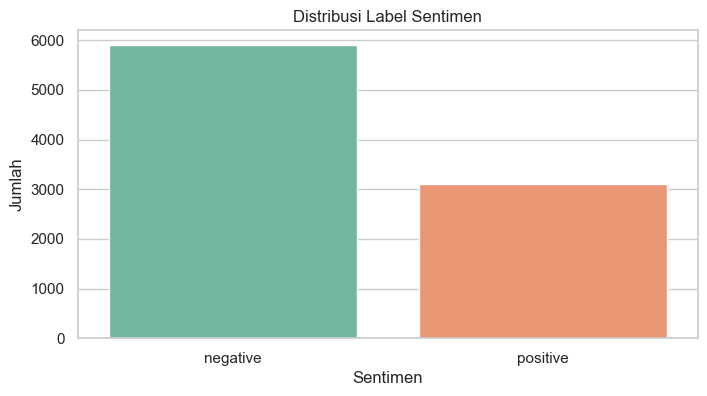

polarity
negative    5906
positive    3102
Name: count, dtype: int64

In [66]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(
    data=clean_df,
    x="polarity",
    order=["negative", "positive"],
    palette="Set2",
    hue="polarity",
    legend=False
  )
ax.set_title("Distribusi Label Sentimen")
ax.set_xlabel("Sentimen")
ax.set_ylabel("Jumlah")
plt.show()

clean_df["polarity"].value_counts()

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Pisahkan data menjadi fitur (tweet) dan label (sentimen)
X = clean_df['text_akhir']
y = clean_df['polarity']
 
# Ekstraksi fitur dengan TF-IDF
tfidf = TfidfVectorizer(max_features=200, min_df=17, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)
 
# Konversi hasil ekstraksi fitur menjadi dataframe
features_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
 
# Menampilkan hasil ekstraksi fitur
features_df
 

,acara,adil,aktif,akun,aman,aneh,banget,beda,beli,bener,...,tim,tolong,tombol,top,trus,tuh,turun,uang,ulang,wifi
0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.135464,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
1,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.214873,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.277180,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
3,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.257487
4,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.118811,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.421341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9003,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
9004,0.241635,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.303522,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
9005,0.534946,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
9006,0.387342,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.0,0.0,0.0,0.0,0.474171,0.0,0.0,0.000000


In [68]:

# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)